<a href="https://colab.research.google.com/github/Faiq-danZ/sentimen-analisis-shopee-lstm./blob/main/LSTM_Shopee_Reviews_Ahmad_Faiq.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
!pip install google-play-scraper sastrawi wordcloud

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import re
import string
import nltk
import csv
import requests
from io import StringIO

# Scraper & Preprocessing
from google_play_scraper import app, reviews, Sort, reviews_all
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from wordcloud import WordCloud

# Machine Learning & Evaluation
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Deep Learning
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping

# Konfigurasi
pd.options.mode.chained_assignment = None
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)

# Download NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

print("Library berhasil diimpor dan siap digunakan.")

Library berhasil diimpor dan siap digunakan.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [17]:
# 1. Scraping Data Masif (Target 10.000+)
print("Memulai proses scraping besar-besaran... Harap tunggu sebentar.")

# Menarik ulasan dalam jumlah banyak (10.000+)
shopee_reviews, _ = reviews(
    'com.shopee.id',
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=12000,
)

# Konversi hasil scraping ke DataFrame
df_raw = pd.DataFrame(shopee_reviews)

# Pilih kolom penting: content (teks) dan score (rating)
df_final = df_raw[['content', 'score']].copy()
df_final.columns = ['text_preprocessed', 'score']

# --- VALIDASI JUMLAH DATA ---
jumlah_data = len(df_final)
if jumlah_data >= 10000:
    print(f"MANTAP! Target tercapai. Berhasil mendapatkan {jumlah_data} ulasan.")
else:
    print(f"Peringatan: Baru mendapatkan {jumlah_data} ulasan. Coba jalankan ulang atau ganti sort ke Sort.MOST_RELEVANT.")

# Simpan ke CSV untuk digunakan di Notebook Pelatihan
df_final.to_csv('dataset_shopee_reviews.csv', index=False)

# Menampilkan 5 data teratas dan total info
print(df_final.info())
df_final.head()

Memulai proses scraping besar-besaran... Harap tunggu sebentar.
MANTAP! Target tercapai. Berhasil mendapatkan 12000 ulasan.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   text_preprocessed  12000 non-null  object
 1   score              12000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 187.6+ KB
None


,text_preprocessed,score
0,shopee sangat mantul dan sangat aku suka 🫰😄,5
1,males banget belanja disini. ekspedisi semrawu...,1
2,"so soan mau adain fitur pengembalian,tapi bara...",1
3,Jangan terlalu banyak biaya penanganannya,4
4,OK,5


In [18]:
# 2. Membaca file dataset dan memberikan label
df = pd.read_csv('dataset_shopee_reviews.csv')

# Fungsi untuk menentukan label berdasarkan skor rating
def tentukan_label(score):
    if score >= 4:
        return 'positive'
    elif score <= 2:
        return 'negative'
    else:
        return 'neutral'

df['label'] = df['score'].apply(tentukan_label)

# (fokus ke Positif vs Negatif)
df_clean = df[df['label'] != 'neutral'].copy()

# Mengubah label teks jadi angka (Wajib untuk AI: Positive=1, Negative=0)
df_clean['label_bin'] = df_clean['label'].apply(lambda x: 1 if x == 'positive' else 0)

print("Tahap 2 Selesai: Data berhasil dimuat!")
print(f"Total data ulasan yang akan dipelajari AI: {len(df_clean)} sampel")
print("\nRincian jumlah data per kategori:")
print(df_clean['label'].value_counts())

Tahap 2 Selesai: Data berhasil dimuat!
Total data ulasan yang akan dipelajari AI: 11553 sampel

Rincian jumlah data per kategori:
label
positive    8747
negative    2806
Name: count, dtype: int64


In [19]:
# 3. Memberikan label sentimen (Positif/Negatif) dan membersihkan data

# Fungsi labeling
def set_label(score):
    if score >= 4: return 'positive'
    elif score <= 2: return 'negative'
    else: return 'neutral'

df_final['label'] = df_final['score'].apply(set_label)

# Hapus data neutral agar AI lebih fokus dan akurasi tinggi (Binary Classification)
df_clean = df_final[df_final['label'] != 'neutral'].copy()

# Mapping label ke angka: Positive = 1, Negative = 0
df_clean['label_bin'] = df_clean['label'].apply(lambda x: 1 if x == 'positive' else 0)

print("Tahap 3 Selesai!")
print(f"Data siap dilatih: {len(df_clean)} ulasan")
print(df_clean['label'].value_counts())

Tahap 3 Selesai!
Data siap dilatih: 11553 ulasan
label
positive    8747
negative    2806
Name: count, dtype: int64


In [20]:
# 4. Tokenisasi: Mengubah teks menjadi urutan angka
# ambil 5.000 kata yang paling sering muncul dalam dataset
max_words = 5000
max_len = 100 # Setiap ulasan batasi panjangnya maksimal 100 kata

# Inisialisasi Tokenizer (Kamus AI)
tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(df_clean['text_preprocessed'].astype(str))

# Mengubah teks ulasan menjadi angka (Sequences)
X = tokenizer.texts_to_sequences(df_clean['text_preprocessed'].astype(str))

# Padding: Menyamakan panjang semua ulasan agar seragam (100 kata)
X = pad_sequences(X, maxlen=max_len)

# Mengambil label (Target) yang sudah jadi angka (0 atau 1)
y = df_clean['label_bin'].values

# Split Data: 80% untuk Belajar (Train) dan 20% untuk Ujian (Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Tahap 4 Selesai!")
print(f"Dataset berhasil diubah jadi angka.")
print(f"Data latih: {X_train.shape[0]} sampel")
print(f"Data uji: {X_test.shape[0]} sampel")

Tahap 4 Selesai!
Dataset berhasil diubah jadi angka.
Data latih: 9242 sampel
Data uji: 2311 sampel


In [21]:
# 5. Membangun Arsitektur Model AI (LSTM)
model = Sequential([
    # Layer 1: Embedding (Mengubah angka ID kata menjadi vektor dimensi)
    Embedding(input_dim=5000, output_dim=64, input_length=100),
    SpatialDropout1D(0.2),

    # Layer 2: LSTM (Inti dari model untuk memahami konteks kalimat)
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),

    # Layer 3: Dense (Output layer dengan aktivasi Sigmoid untuk klasifikasi 0 atau 1)
    Dense(1, activation='sigmoid')
])

# Kompilasi model
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()
print("\nTahap 5 Selesai: Arsitektur LSTM sudah siap!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Tahap 5 Selesai: Arsitektur LSTM sudah siap!


In [22]:
# 6. Memulai proses pelatihan model
print("Proses training dimulai... Harap tunggu (bisa memakan waktu beberapa menit).")

# gunakan callbacks agar jika akurasi sudah bagus, proses berhenti otomatis
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

history = model.fit(
    X_train, y_train,
    epochs=10, # Kita coba 10 putaran belajar
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[callback],
    verbose=1
)

print("\nTahap 6 Selesai: Model sudah pintar!")

Proses training dimulai... Harap tunggu (bisa memakan waktu beberapa menit).
Epoch 1/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 45s 191ms/step - accuracy: 0.8321 - loss: 0.3866 - val_accuracy: 0.8823 - val_loss: 0.2841
Epoch 2/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 29s 201ms/step - accuracy: 0.9158 - loss: 0.2203 - val_accuracy: 0.8979 - val_loss: 0.2522
Epoch 3/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 26s 179ms/step - accuracy: 0.9393 - loss: 0.1688 - val_accuracy: 0.9070 - val_loss: 0.2466
Epoch 4/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 39s 170ms/step - accuracy: 0.9514 - loss: 0.1374 - val_accuracy: 0.9070 - val_loss: 0.2653
Epoch 5/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 41s 170ms/step - accuracy: 0.9628 - loss: 0.1156 - val_accuracy: 0.9035 - val_loss: 0.2842
Epoch 6/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 23s 157ms/step - accuracy: 0.9707 - loss: 0.0978 - val_accuracy: 0.9031 - val_loss: 0.3061

Tahap 6 Selesai: Model sudah pintar!



--- TEST PREDIKSI ---
Input: Barangnya bagus banget, pengiriman cepat sampai tujuan!
HASIL: POSITIF (Skor: 1.00)

Input: Aplikasi jelek, sering error dan CS tidak membantu sama sekali.
HASIL: NEGATIF (Skor: 0.07)


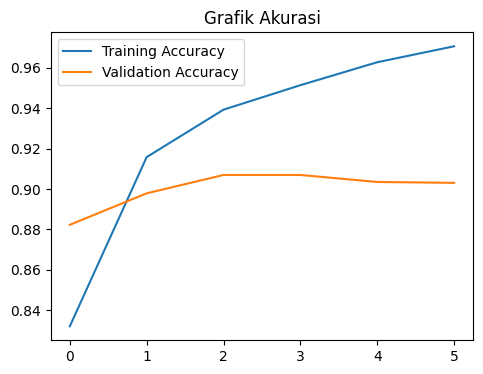

In [23]:
# 7. Visualisasi Hasil & Tes Prediksi Mandiri

# A. Menampilkan Grafik Akurasi
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Grafik Akurasi')
plt.legend()

# B. Fungsi untuk Tes Ulasan Baru
def prediksi_sentimen(kalimat):
    # Preprocessing singkat
    seq = tokenizer.texts_to_sequences([kalimat])
    padded = pad_sequences(seq, maxlen=max_len)

    # Prediksi
    prediksi = model.predict(padded, verbose=0)

    if prediksi >= 0.5:
        return f"HASIL: POSITIF (Skor: {prediksi[0][0]:.2f})"
    else:
        return f"HASIL: NEGATIF (Skor: {prediksi[0][0]:.2f})"

# Di bawah ini untuk ngetestnya
print("\n--- TEST PREDIKSI ---")
test_chat = "Barangnya bagus banget, pengiriman cepat sampai tujuan!"
print(f"Input: {test_chat}")
print(prediksi_sentimen(test_chat))

test_chat_2 = "Aplikasi jelek, sering error dan CS tidak membantu sama sekali."
print(f"\nInput: {test_chat_2}")
print(prediksi_sentimen(test_chat_2))

In [24]:
# 8. Menyimpan Model dan Tokenizer (Agar bisa dipakai lagi nanti)
import pickle
model.save('model_sentimen_ahmad faiq zidane.h5')

with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

print("Model dan Tokenizer berhasil disimpan!")

Model dan Tokenizer berhasil disimpan!


In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
# --- CELL INFERENCE (SARAN KE-6) ---
# Cell ini mensimulasikan penggunaan model seolah-olah di aplikasi nyata
import tensorflow as tf
import pickle
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 1. Load Model yang sudah disimpan
loaded_model = tf.keras.models.load_model('model_sentimen_ahmad faiq zidane.h5')

# 2. Load Tokenizer yang sudah disimpan
with open('tokenizer.pickle', 'rb') as handle:
    loaded_tokenizer = pickle.load(handle)

# 3. Fungsi Prediksi
def inference_test(kalimat):
    seq = loaded_tokenizer.texts_to_sequences([kalimat])
    padded = pad_sequences(seq, maxlen=100)
    hasil = loaded_model.predict(padded, verbose=0)
    return "Positif" if hasil >= 0.5 else "Negatif"

# 4. Tes
print(f"Hasil Tes Inference: {inference_test('Wah, layanannya mantap banget!')}")

Hasil Tes Inference: Positif


In [34]:
# Cara otomatis ala 'pip freeze' tapi filter yang penting saja
!pip freeze | grep -E "pandas|numpy|matplotlib|seaborn|scikit-learn|tensorflow|google-play-scraper" > requirements.txt